# Tier 2 (Person C): CNN + BiLSTM on **Mel** with **Mixup**

## What this notebook does
- Loads the same preprocessed 3-second audio chunks from HuggingFace as Person A
- Extracts **80 log-Mel bins** — i.e. it switches **back to A's representation**
  (MFCC lived *only* in C Tier 1; from Tier 2 onward C is on Mel to stay aligned with A)
- Applies the **same** SpecAugment during training
- Adds **Mixup** on top of SpecAugment — the *one* new variable versus A's Tier 2
- Trains the **same** CNN + BiLSTM classifier (byte-for-byte A's Tier 2 architecture)
- Evaluates per-language accuracy, macro-F1, confusion matrix, t-SNE
- Saves a `results.json` with all metrics (team reporting convention)

## Research question for this tier
**Does Mixup help on top of SpecAugment?** — C Tier 2 vs A Tier 2. The *only* thing that
changes versus A is the addition of Mixup. Features (80 log-Mel), front-end FFT settings,
SpecAugment params, model, optimizer, schedule, seed, and splits are all identical, so any
accuracy difference is attributable to Mixup alone. The clean no-Mixup baseline is **A's
actual Tier 2 run** (A is the anchor: Mel + SpecAugment, no Mixup), so this notebook does
**not** retrain a no-Mixup twin — the comparison is read directly against A's reported numbers.

## Conventions honoured
Same dataset/splits, seed = 42, **Tier 2 = 40 epochs** (team default), per-language accuracy
+ macro-F1 + confusion matrix, and a `results.json` dump at the end.

## Languages
Belarussian, Bulgarian, Czech, Macedonian, Polish, Russian, Serbian, Ukranian


In [1]:
# Kaggle already ships torch / torchaudio / librosa / sklearn / matplotlib / seaborn with the
# correct CUDA build — do NOT reinstall those (pip can pull a mismatched or CPU-only build and
# break GPU). We only refresh the HuggingFace stack. Requires Internet = ON in notebook settings.
!pip install -q -U datasets huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 114.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.


In [2]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from datasets import load_dataset, Audio
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
# Add your token under  Add-ons -> Secrets  with the label "HF_TOKEN", then attach it here.
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

try:
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    login(token=hf_token)
    print("Logged in to HuggingFace.")
except Exception as e:
    print(f"No usable HF_TOKEN secret ({e}). Continuing unauthenticated — "
          "OK if the dataset is public, will fail if it is gated.")

Logged in to HuggingFace.


In [4]:
REPO_ID = "su-fmi-pytorch-slavic/slavic-languages-dataset"

In [5]:
import glob

# Kaggle has no Google Drive. We cache to /kaggle/working (which is saved as the notebook's
# output when you 'Save Version'). To REUSE the cache across sessions, either:
#   (a) Settings -> Persistence -> "Files only"  (keeps /kaggle/working between sessions), or
#   (b) Save a version, then attach this notebook's output as an input dataset.
# We also scan /kaggle/input, so a pre-built cache attached as a dataset is picked up auto-
# matically. Folder name kept distinct from A / from C's Tier 1 so nothing collides if shared.
CACHE_DIR = "/kaggle/working/slavic_lid"
CKPT_DIR = f"{CACHE_DIR}/tier2_mixup"
CACHE_NPZ_TRAIN = f"{CACHE_DIR}/train_logmel_f16.npz"   # write target (working dir)
CACHE_NPZ_TEST  = f"{CACHE_DIR}/test_logmel_f16.npz"
os.makedirs(CKPT_DIR, exist_ok=True)

def _find_cache(fname):
    '''Look in the working cache first, then anywhere under /kaggle/input.'''
    local = f"{CACHE_DIR}/{fname}"
    if os.path.exists(local):
        return local
    hits = glob.glob(f"/kaggle/input/**/{fname}", recursive=True)
    return hits[0] if hits else None

train_cache = _find_cache("train_logmel_f16.npz")
test_cache  = _find_cache("test_logmel_f16.npz")

if train_cache and test_cache:
    print("log-Mel cache found — loading (skipping HuggingFace download)...")
    print(f"  train: {train_cache}")
    print(f"  test:  {test_cache}")
    d = np.load(train_cache)
    X_train, y_train = d["X"], d["y"]
    d = np.load(test_cache)
    X_test, y_test = d["X"], d["y"]
    raw = None
    print(f"  Train: {X_train.shape}  ({X_train.nbytes / 1e9:.2f} GB in RAM)")
    print(f"  Test:  {X_test.shape}  ({X_test.nbytes / 1e9:.2f} GB in RAM)")
    print("Ready — skip to the 'Dataset classes' cell.")
else:
    print("No log-Mel cache found. Downloading raw dataset from HuggingFace...")
    print("(Runs once. Cache is written to /kaggle/working so you can reuse it next session.)")
    raw = load_dataset(REPO_ID)
    X_train = y_train = X_test = y_test = None
    print(raw)

No log-Mel cache found. Downloading raw dataset from HuggingFace...
(Runs once. Cache is written to /kaggle/working so you can reuse it next session.)


README.md:   0%|          | 0.00/694 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

data/train-00000-of-00016.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/80000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/107439 [00:00<?, ? examples/s]

Generating eval_fleurs split:   0%|          | 0/6157 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['audio', 'language', 'label', 'source', 'speaker_id'],
        num_rows: 80000
    })
    test: Dataset({
        features: ['audio', 'language', 'label', 'source', 'speaker_id'],
        num_rows: 107439
    })
    eval_fleurs: Dataset({
        features: ['audio', 'language', 'label', 'source', 'speaker_id'],
        num_rows: 6157
    })
})


In [6]:
# Sanity check: /kaggle/working is writable (Kaggle persists it as the notebook output)
assert os.path.isdir("/kaggle/working"), "/kaggle/working missing — are you running on Kaggle?"
print("Working dir confirmed:", CACHE_DIR)

Working dir confirmed: /kaggle/working/slavic_lid


In [7]:
if raw is not None:
    sample = raw["train"][0]
    print("Keys:", list(sample.keys()))
    print("Language:", sample["language"])
    print("Label:", sample["label"])
    print("Source:", sample["source"])
    print("Audio array shape:", np.array(sample["audio"]["array"]).shape)
    print("Audio sampling rate:", sample["audio"]["sampling_rate"])
else:
    print("Skipping sample inspection — using pre-cached log-Mels.")

Keys: ['audio', 'language', 'label', 'source', 'speaker_id']
Language: be
Label: 0
Source: mcv
Audio array shape: (48000,)
Audio sampling rate: 16000


## Feature Extraction: 80 log-Mel bins (back to A's representation)

Tier 2 returns to A's **exact** front-end, so the only difference versus A's Tier 2 is Mixup.

Key choices that keep the comparison fair:
- **Same front-end as A**: `n_fft=400`, `hop_length=160`, `n_mels=80`, `f_min=20`, `f_max=8000`.
  → time axis is 300 frames, identical to A.
- **log compression**: `AmplitudeToDB` on the power mel-spectrogram (standard log-Mel in dB).
- **Normalization**: A's canonical **global per-sample** normalization — a single mean/std
  over the whole 80×300 map (zero-mean / unit-var). This is the correct, fair treatment for
  log-Mel (all 80 bins live on the same dB scale), and is exactly what A uses. (Contrast with
  C Tier 1, where MFCC needed *per-coefficient* CMVN — that subtlety is gone now that we are
  back on Mel.)
- **SpecAugment kept identical** (F=15 ×2, T=40 ×2), applied after normalization, same as A.

**Mixup** is applied separately, at the batch level in the training loop (see the Mixup
section), so the cached features are plain log-Mels and the augmentation pipeline stays a
clean superset of A's.


In [8]:
SAMPLE_RATE = 16_000
N_FFT = 400
HOP_LENGTH = 160
N_MELS = 80            # log-Mel bins fed straight to the CNN (same as A)
N_FEAT = N_MELS        # 80-dim feature axis
TARGET_LENGTH = 300
FREQ_MASK_F = 15
TIME_MASK_T = 40

LANGUAGES = ["be", "bg", "cs", "mk", "pl", "ru", "sr", "uk"]
LANG2ID = {lang: i for i, lang in enumerate(sorted(LANGUAGES))}
ID2LANG = {v: k for k, v in LANG2ID.items()}

# Mel front-end: byte-for-byte A's MelSpectrogram, then log (dB).
mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    f_min=20,
    f_max=8000,
)
amplitude_to_db = T.AmplitudeToDB(stype="power", top_db=80.0)


def waveform_to_logmel(waveform: torch.Tensor) -> torch.Tensor:
    '''Raw 80-bin log-Mel (dB), padded/cropped to TARGET_LENGTH. No normalization here —
    normalization happens in build_feature so it can be reused on the FLEURS eval too.'''
    mel = mel_transform(waveform.unsqueeze(0)).squeeze(0)     # (N_MELS, T) power
    logmel = amplitude_to_db(mel)                             # (N_MELS, T) dB
    cur_len = logmel.shape[-1]
    if cur_len < TARGET_LENGTH:
        logmel = F.pad(logmel, (0, TARGET_LENGTH - cur_len))
    else:
        logmel = logmel[..., :TARGET_LENGTH]
    return logmel                                             # (80, 300)


def build_feature(logmel: torch.Tensor) -> torch.Tensor:
    '''80-bin log-Mel -> globally normalized (1, 80, 300) tensor ready for the CNN.
    Global per-sample norm = A's canonical log-Mel normalization.'''
    mean = logmel.mean()
    std = logmel.std() + 1e-6
    feat = (logmel - mean) / std
    return feat.unsqueeze(0)                                  # (1, 80, 300)


# SpecAugment — IDENTICAL params to A (kept fixed so it is not a confound).
specaugment_train = nn.Sequential(
    T.FrequencyMasking(freq_mask_param=FREQ_MASK_F),
    T.FrequencyMasking(freq_mask_param=FREQ_MASK_F),
    T.TimeMasking(time_mask_param=TIME_MASK_T),
    T.TimeMasking(time_mask_param=TIME_MASK_T),
)

In [9]:
# ── Extract log-Mels and cache to /kaggle/working (only runs when no cache exists) ─
# On the FIRST run this takes a few minutes and writes the cache to /kaggle/working.
# Every restart after that jumps straight to "log-Mel cache found" in the cell above.

if raw is not None:
    def _extract_logmel(split, desc):
        n = len(split)
        X = np.empty((n, N_MELS * TARGET_LENGTH), dtype=np.float16)   # 80*300
        y = np.empty(n, dtype=np.int32)
        for i, ex in enumerate(tqdm(split, desc=desc, total=n)):
            wav = torch.tensor(ex["audio"]["array"], dtype=torch.float32)
            logmel = waveform_to_logmel(wav)
            X[i] = logmel.numpy().flatten().astype(np.float16)
            y[i] = int(ex["label"])
        return X, y

    print("Extracting train log-Mels (runs once, cached to /kaggle/working)...")
    X_train, y_train = _extract_logmel(raw["train"], "Train")
    np.savez_compressed(CACHE_NPZ_TRAIN, X=X_train, y=y_train)
    print(f"  Saved {os.path.getsize(CACHE_NPZ_TRAIN) / 1e9:.2f} GB to {CACHE_NPZ_TRAIN}")

    print("Extracting test log-Mels...")
    X_test, y_test = _extract_logmel(raw["test"], "Test")
    np.savez_compressed(CACHE_NPZ_TEST, X=X_test, y=y_test)
    print(f"  Saved {os.path.getsize(CACHE_NPZ_TEST) / 1e9:.2f} GB to {CACHE_NPZ_TEST}")

    del raw
    import gc; gc.collect()
    print("\nDone! Cache written to /kaggle/working — reuse it next session via Persistence or as a dataset.")
else:
    print("Cache already loaded — nothing to do here.")

print(f"\nTrain: {len(y_train):,} samples | Test: {len(y_test):,} samples")

Extracting train log-Mels (runs once, cached to /kaggle/working)...


Train:   0%|          | 0/80000 [00:00<?, ?it/s]

  Saved 2.80 GB to /kaggle/working/slavic_lid/train_logmel_f16.npz
Extracting test log-Mels...


Test:   0%|          | 0/107439 [00:00<?, ?it/s]

  Saved 3.44 GB to /kaggle/working/slavic_lid/test_logmel_f16.npz

Done! Cache written to /kaggle/working — reuse it next session via Persistence or as a dataset.

Train: 80,000 samples | Test: 107,439 samples


In [10]:
class SlavicLIDDataset(Dataset):
    '''Reads pre-extracted 80-bin log-Mels, globally normalizes, and optionally applies
    SpecAugment. Mixup is NOT applied here — it is a batch-level op in the training loop.'''
    def __init__(self, X: np.ndarray, y: np.ndarray, augment: bool = False):
        self.X = X          # shape (N, N_MELS * TARGET_LENGTH), dtype float16
        self.y = y          # shape (N,), dtype int32
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        logmel = torch.from_numpy(self.X[idx].astype(np.float32)).reshape(N_MELS, TARGET_LENGTH)
        feat = build_feature(logmel)          # (1, 80, 300), globally normalized
        if self.augment:
            feat = specaugment_train(feat)
        return feat, int(self.y[idx])

In [11]:
ds_tmp = SlavicLIDDataset(X_train, y_train, augment=False)
spec_clean, label = ds_tmp[42]

ds_aug = SlavicLIDDataset(X_train, y_train, augment=True)
spec_aug, _ = ds_aug[42]

Visualize a sample feature map (80 log-Mel bins), clean vs SpecAugment

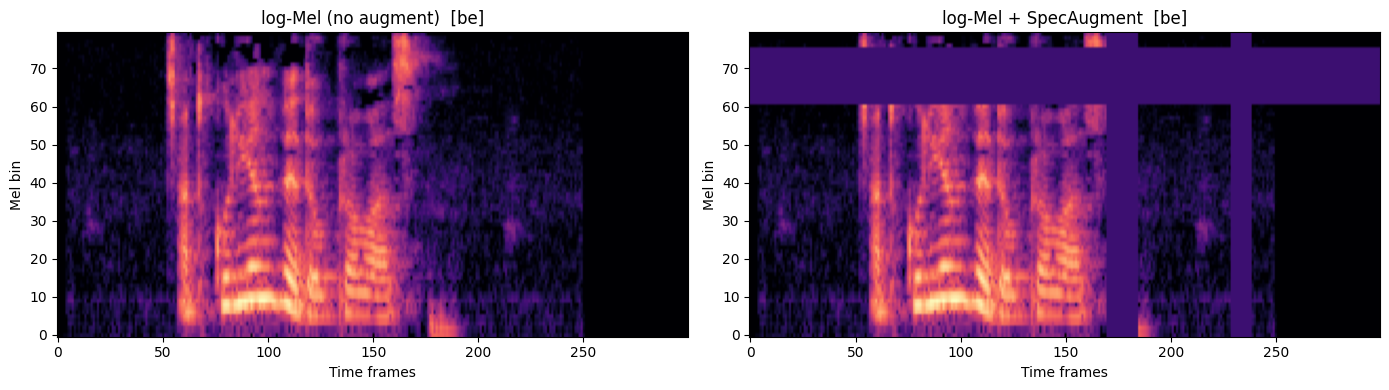

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, spec, title in zip(axes,
                            [spec_clean, spec_aug],
                            ["log-Mel (no augment)", "log-Mel + SpecAugment"]):
    ax.imshow(spec.squeeze().numpy(), origin="lower", aspect="auto", cmap="magma")
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bin")
    ax.set_title(f"{title}  [{ID2LANG[label]}]")

plt.tight_layout()
plt.show()

Dataloaders

In [13]:
BATCH_SIZE = 32

# Small random subset of the test set used for fast per-epoch validation (same seed/size as A)
rng = np.random.default_rng(42)
small_idx = rng.choice(len(y_test), size=min(16_000, len(y_test)), replace=False)

train_dataset      = SlavicLIDDataset(X_train,           y_train,           augment=True)
test_small_dataset = SlavicLIDDataset(X_test[small_idx], y_test[small_idx], augment=False)
test_full_dataset  = SlavicLIDDataset(X_test,            y_test,            augment=False)

train_loader      = DataLoader(train_dataset,      batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True, persistent_workers=True)
test_small_loader = DataLoader(test_small_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_full_loader  = DataLoader(test_full_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

print(f"Train:      {len(train_dataset):,} samples")
print(f"Test small: {len(test_small_dataset):,} samples  (used during training)")
print(f"Test full:  {len(test_full_dataset):,} samples  (used for final eval)")

Train:      80,000 samples
Test small: 16,000 samples  (used during training)
Test full:  107,439 samples  (used for final eval)


## Model Architecture — CNN + BiLSTM

This is **byte-for-byte Person A's Tier 2** architecture: the same conv front-end as the
Tier 1 CNN, but instead of collapsing everything with a global pool, we **keep the time axis**,
mean-pool over the frequency axis, and feed the resulting sequence to a **2-layer BiLSTM**,
then **mean-pool over time** and classify. Keeping the model identical to A is exactly what
isolates **Mixup** as the only variable for the C-vs-A Tier 2 comparison.

Flow: `(1, 80, 300)` → conv stack → `(256, 10, 37)` → mean over freq → `(256, 37)` →
`(37, 256)` → BiLSTM(2×128, bidirectional) → `(37, 256)` → mean over time → `(256,)` →
embed `(128,)` → logits `(8,)`.


In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

In [15]:
class CNNBiLSTM(nn.Module):
    '''Identical architecture to Person A's Tier 2: CNN front-end (same ConvBlocks as the
    Tier 1 CNN) -> frequency pooled -> 2-layer BiLSTM -> mean pooling over time -> head.'''
    def __init__(self, n_classes: int = 8, lstm_hidden: int = 128, lstm_layers: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32), nn.MaxPool2d(2, 2),
            ConvBlock(32, 64), nn.MaxPool2d(2, 2),
            ConvBlock(64, 128), nn.MaxPool2d(2, 2),
            ConvBlock(128, 256),
        )
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3,
        )
        self.embed = nn.Sequential(
            nn.Linear(2 * lstm_hidden, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Linear(128, n_classes)

    def _embed(self, x):
        h = self.features(x)          # (B, 256, F', T')
        h = h.mean(dim=2)             # (B, 256, T')   pool over frequency
        h = h.permute(0, 2, 1)        # (B, T', 256)
        seq, _ = self.lstm(h)         # (B, T', 2*hidden)
        pooled = seq.mean(dim=1)      # (B, 2*hidden)  mean pooling over time
        return self.embed(pooled)     # (B, 128)

    def forward(self, x):
        return self.classifier(self._embed(x))

    def get_embeddings(self, x):
        return self._embed(x)

In [16]:
model = CNNBiLSTM(n_classes=8).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

dummy = torch.zeros(4, 1, N_FEAT, TARGET_LENGTH).to(DEVICE)   # (4, 1, 80, 300)
print(f"Output shape: {model(dummy).shape}")
print(f"Embedding shape: {model.get_embeddings(dummy).shape}")

Trainable parameters: 1,212,776
Output shape: torch.Size([4, 8])
Embedding shape: torch.Size([4, 128])


## Mixup — the one new variable vs A's Tier 2

Mixup forms convex combinations of pairs of training examples *and* their labels:

> x̃ = λ·xᵢ + (1−λ)·xⱼ,  ỹ = λ·yᵢ + (1−λ)·yⱼ,  with  λ ~ Beta(α, α)

We implement it at the **input (log-Mel) level**, per batch, by pairing each sample with a
shuffled partner from the same batch. Because cross-entropy is linear in the one-hot target,
the mixed loss is simply `λ·CE(logits, yᵢ) + (1−λ)·CE(logits, yⱼ)` — no need to materialize
soft targets.

- **α = 0.2** (standard, mild mixing).
- Mixup is applied **after** SpecAugment and **only** during training; validation, final test,
  and the FLEURS eval never use it.
- A's Tier 2 has **no** Mixup, so this is the single isolated variable for C Tier 2 vs A Tier 2.

The "soft" training accuracy reported during the mixed run is `λ·acc(yᵢ) + (1−λ)·acc(yⱼ)`,
which is just a monitoring signal — the meaningful number is the clean test accuracy.


In [17]:
MIXUP_ALPHA = 0.2

def mixup_batch(x, y, alpha):
    '''Return mixed inputs, the two label sets, and the mixing coefficient lam.'''
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_ce(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)

Training setup (hyperparameters identical to A; **40 epochs** per team convention)

In [18]:
EPOCHS = 40          # team convention: Tier 2 = 40 epochs
LR = 1e-3
WD = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [19]:
def run_epoch(model, loader, criterion, optimizer, train: bool, mixup_alpha=None):
    '''One pass over `loader`. If train and mixup_alpha is not None, applies batch Mixup.'''
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for specs, labels in tqdm(loader, leave=False):
            specs, labels = specs.to(DEVICE), labels.to(DEVICE)

            if train and mixup_alpha is not None:
                mixed, y_a, y_b, lam = mixup_batch(specs, labels, mixup_alpha)
                logits = model(mixed)
                loss = mixup_ce(criterion, logits, y_a, y_b, lam)
                preds = logits.argmax(1)
                # soft accuracy (monitoring only)
                correct += (lam * (preds == y_a).float()
                            + (1.0 - lam) * (preds == y_b).float()).sum().item()
            else:
                logits = model(specs)
                loss = criterion(logits, labels)
                correct += (logits.argmax(1) == labels).sum().item()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)

    return total_loss / total, correct / total

In [20]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

In [21]:
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer,
                                train=True, mixup_alpha=MIXUP_ALPHA)
    te_loss, te_acc = run_epoch(model, test_small_loader, criterion, optimizer,
                                train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"Test  loss {te_loss:.4f} acc {te_acc:.3f}")

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch   1/40 | Train loss 1.7543 acc 0.319 | Test  loss 1.9440 acc 0.278


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch  40/40 | Train loss 0.6058 acc 0.819 | Test  loss 2.6164 acc 0.379


Save a checkpoint to /kaggle/working

In [22]:
torch.save({
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "history": history,
    "hparams": {"features": "logmel80", "arch": "cnn+bilstm",
                "augment": "specaugment+mixup", "mixup_alpha": MIXUP_ALPHA,
                "epochs": EPOCHS, "lr": LR, "batch": BATCH_SIZE},
}, f"{CKPT_DIR}/mixup_cnn_bilstm_final.pt")

print(f"Checkpoint saved to {CKPT_DIR}/mixup_cnn_bilstm_final.pt")

Checkpoint saved to /kaggle/working/slavic_lid/tier2_mixup/mixup_cnn_bilstm_final.pt


Learning curves

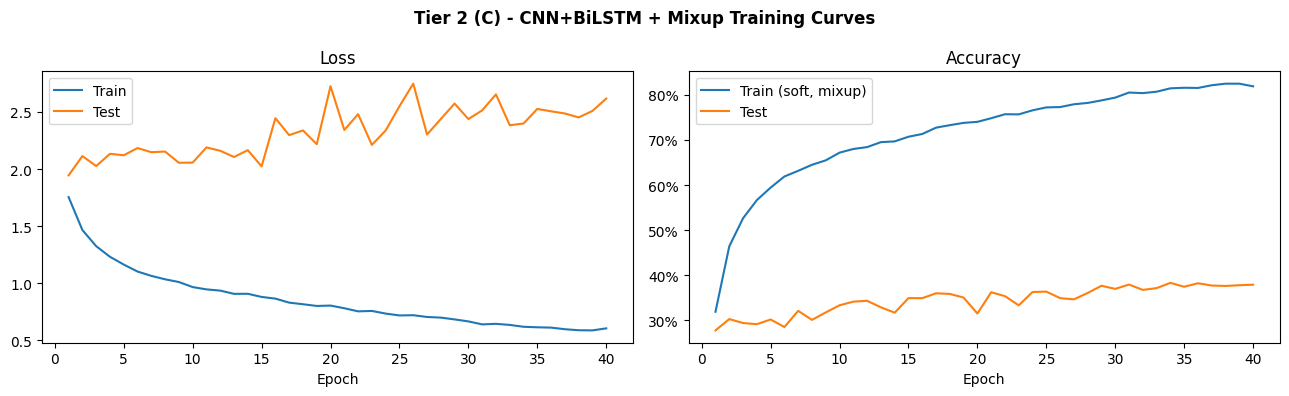

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, EPOCHS + 1)
ax1.plot(epochs, history["train_loss"], label="Train")
ax1.plot(epochs, history["test_loss"],  label="Test")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs, history["train_acc"], label="Train (soft, mixup)")
ax2.plot(epochs, history["test_acc"],  label="Test")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle("Tier 2 (C) - CNN+BiLSTM + Mixup Training Curves", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/learning_curves.png", dpi=150)
plt.show()

## Evaluation

In [24]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for specs, labels in tqdm(test_full_loader, desc="Evaluating"):
        specs  = specs.to(DEVICE)
        preds  = model(specs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

overall_acc = (all_preds == all_labels).mean()
macro_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"\nOverall Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"Macro-F1 : {macro_f1:.4f}")
print()

print(classification_report(all_labels, all_preds, target_names=LANGUAGES, digits=3))

Evaluating:   0%|          | 0/3358 [00:00<?, ?it/s]


Overall Accuracy: 0.3780 (37.80%)
Macro-F1 : 0.2377

              precision    recall  f1-score   support

          be      0.511     0.791     0.621     29232
          bg      0.396     0.035     0.063      6318
          cs      0.299     0.132     0.183     14441
          mk      0.225     0.143     0.175      3263
          pl      0.340     0.207     0.258     16949
          ru      0.276     0.500     0.356     19069
          sr      0.146     0.078     0.102      1666
          uk      0.231     0.105     0.144     16501

    accuracy                          0.378    107439
   macro avg      0.303     0.249     0.238    107439
weighted avg      0.350     0.378     0.330    107439



Confusion matrix

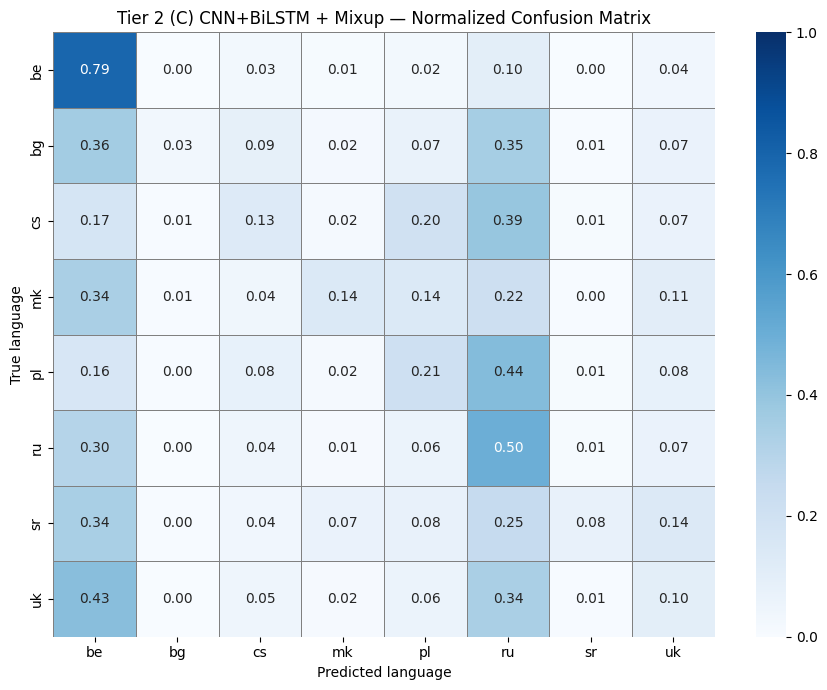

In [25]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LANGUAGES, yticklabels=LANGUAGES, ax=ax,
            linewidths=0.5, linecolor="gray", vmin=0, vmax=1)

ax.set_xlabel("Predicted language")
ax.set_ylabel("True language")
ax.set_title("Tier 2 (C) CNN+BiLSTM + Mixup — Normalized Confusion Matrix")

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

## t-SNE of learned embeddings (stratified, class-balanced)

To keep the t-SNE picture from being dominated by the larger languages, we extract embeddings
over the **full** test set and then **stratified-subsample**: take the *same* number of points
from every language, equal to the size of the **smallest** language in the test set. This makes
all 8 languages contribute equally to the layout.


Extracting embeddings:   0%|          | 0/3358 [00:00<?, ?it/s]

Per-language test counts: {'be': 29232, 'bg': 6318, 'cs': 14441, 'mk': 3263, 'pl': 16949, 'ru': 19069, 'sr': 1666, 'uk': 16501}
Smallest language -> sampling 1666 points per language (13328 total)
Fitting t-SNE on 13,328 points (perplexity=40)...


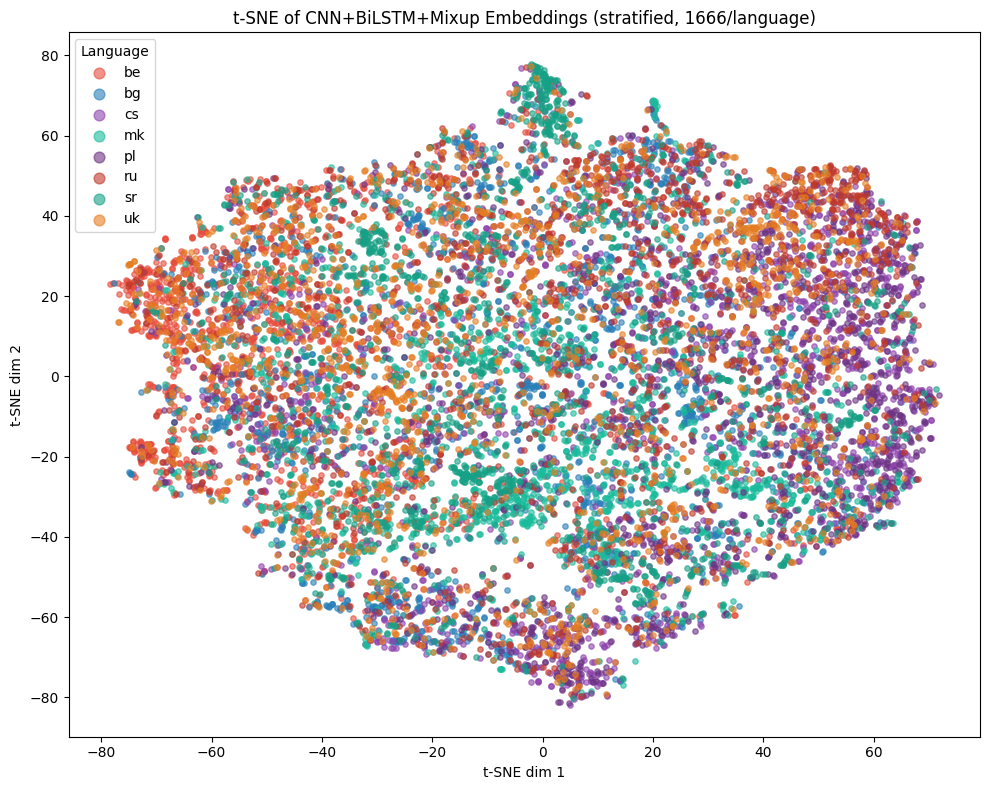

In [26]:
# 1) Embed the FULL test set (so every language is fully represented).
model.eval()
emb_list, lab_list = [], []
with torch.no_grad():
    for specs, lbls in tqdm(test_full_loader, desc="Extracting embeddings"):
        emb = model.get_embeddings(specs.to(DEVICE)).cpu().numpy()
        emb_list.append(emb)
        lab_list.append(np.asarray(lbls))

all_emb = np.concatenate(emb_list, axis=0)
all_lab = np.concatenate(lab_list, axis=0)

# 2) Stratified sampling: per-language size = the SMALLEST language's count.
rng_tsne = np.random.default_rng(SEED)
counts = {i: int((all_lab == i).sum()) for i in ID2LANG}
per_lang = min(counts.values())
print("Per-language test counts:", {ID2LANG[i]: counts[i] for i in ID2LANG})
print(f"Smallest language -> sampling {per_lang} points per language "
      f"({per_lang * len(ID2LANG)} total)")

sel_idx = []
for i in ID2LANG:
    idx_i = np.where(all_lab == i)[0]
    sel_idx.append(rng_tsne.choice(idx_i, size=per_lang, replace=False))
sel_idx = np.concatenate(sel_idx)
rng_tsne.shuffle(sel_idx)

embeddings = all_emb[sel_idx]
labels_tsne = all_lab[sel_idx]

# 3) Fit t-SNE. Perplexity guarded against small sample sizes.
perplexity = int(min(40, max(5, (len(labels_tsne) - 1) // 3)))
print(f"Fitting t-SNE on {len(labels_tsne):,} points (perplexity={perplexity})...")
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=SEED, init="pca")
proj = tsne.fit_transform(embeddings)

BRANCH_COLORS = {
    "be": "#e74c3c",  # East Slavic - red family
    "ru": "#c0392b",
    "uk": "#e67e22",
    "bg": "#2980b9",  # South Slavic - blue family
    "mk": "#1abc9c",
    "sr": "#16a085",
    "cs": "#8e44ad",  # West Slavic - purple family
    "pl": "#6c3483",
}

fig, ax = plt.subplots(figsize=(10, 8))
for lang_id, lang in ID2LANG.items():
    mask = labels_tsne == lang_id
    ax.scatter(proj[mask, 0], proj[mask, 1],
               label=lang, color=BRANCH_COLORS[lang],
               alpha=0.6, s=15)

ax.legend(title="Language", fontsize=10, markerscale=2)
ax.set_title(f"t-SNE of CNN+BiLSTM+Mixup Embeddings "
             f"(stratified, {per_lang}/language)")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/tsne.png", dpi=150)
plt.show()

## Save `results.json` (team reporting convention)

All metrics for this tier in one place, so the cross-person comparison table can be built
automatically. Saved alongside the checkpoint in /kaggle/working.


In [27]:
report_dict = classification_report(
    all_labels, all_preds, target_names=LANGUAGES, digits=4, output_dict=True
)
per_language_acc = {
    lang: float((all_preds[all_labels == i] == i).mean())
    for i, lang in ID2LANG.items()
}

results = {
    "person": "C",
    "tier": 2,
    "features": "logmel80",
    "architecture": "cnn+bilstm",
    "augmentation": "specaugment+mixup",
    "mixup_alpha": MIXUP_ALPHA,
    "seed": SEED,
    "epochs": EPOCHS,
    "split": "test",
    "overall_accuracy": float(overall_acc),
    "macro_f1": float(macro_f1),
    "best_val_accuracy": float(max(history["test_acc"])),
    "per_language_accuracy": per_language_acc,
    "classification_report": report_dict,
    "confusion_matrix_normalized": cm.tolist(),
}

results_path = f"{CKPT_DIR}/results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved metrics to {results_path}")
print(json.dumps({k: results[k] for k in
                  ["overall_accuracy", "macro_f1"]}, indent=2))

Saved metrics to /kaggle/working/slavic_lid/tier2_mixup/results.json
{
  "overall_accuracy": 0.37796330941278306,
  "macro_f1": 0.23774805816088526
}


## FLEURS generalization eval (team `eval_fleurs` split)

The team splits include `eval_fleurs` (an out-of-distribution test set). This block evaluates
the trained Mixup model on it. Features are computed on the fly (the split is small) reusing
the exact same front-end + normalization — no SpecAugment, no Mixup. Skips cleanly if the
split is not present.


In [28]:
fleurs_metrics = None
try:
    fleurs = load_dataset(REPO_ID, split="eval_fleurs")
    print(f"FLEURS split loaded: {len(fleurs):,} samples")

    model.eval()
    f_preds, f_labels = [], []
    with torch.no_grad():
        for ex in tqdm(fleurs, desc="FLEURS eval"):
            wav = torch.tensor(ex["audio"]["array"], dtype=torch.float32)
            feat = build_feature(waveform_to_logmel(wav)).unsqueeze(0).to(DEVICE)  # (1,1,80,300)
            f_preds.append(int(model(feat).argmax(1).item()))
            f_labels.append(int(ex["label"]))

    f_preds, f_labels = np.array(f_preds), np.array(f_labels)
    f_acc = float((f_preds == f_labels).mean())
    f_f1 = float(f1_score(f_labels, f_preds, average="macro"))
    print(f"\nFLEURS accuracy: {f_acc:.4f} | macro-F1: {f_f1:.4f}")
    print(classification_report(f_labels, f_preds, target_names=LANGUAGES, digits=3))

    fleurs_metrics = {"overall_accuracy": f_acc, "macro_f1": f_f1}
    # fold into results.json
    results["fleurs"] = fleurs_metrics
    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Updated {results_path} with FLEURS metrics.")
except Exception as e:
    print(f"Skipping FLEURS eval ({type(e).__name__}: {e}).")

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

FLEURS split loaded: 6,157 samples


FLEURS eval:   0%|          | 0/6157 [00:00<?, ?it/s]


FLEURS accuracy: 0.3003 | macro-F1: 0.2492
              precision    recall  f1-score   support

          be      0.405     0.088     0.144       967
          bg      0.289     0.468     0.358       511
          cs      0.016     0.003     0.005       723
          mk      0.262     0.655     0.374       973
          pl      0.444     0.317     0.370       758
          ru      0.302     0.155     0.205       775
          sr      0.329     0.691     0.445       700
          uk      0.288     0.056     0.094       750

    accuracy                          0.300      6157
   macro avg      0.292     0.304     0.249      6157
weighted avg      0.296     0.300     0.245      6157

Updated /kaggle/working/slavic_lid/tier2_mixup/results.json with FLEURS metrics.


## Tier 2 (C) Results & Conclusions

### 0. Headline comparison — Mixup vs no Mixup  ← this is C's Tier 2 research question
Fill in side by side with **A's reported Tier 2** numbers (same Mel features, same CNN+BiLSTM,
same seed, same 40 epochs — only Mixup differs). A *is* the no-Mixup baseline, so no twin is
retrained here:

| Setup | Overall acc | Macro-F1 |
|---|---|---|
| A — Tier 2 (Mel, SpecAugment only) | XX.X% | 0.XXX |
| C — Tier 2 (Mel, SpecAugment **+ Mixup**) | XX.X% | 0.XXX |

- Does Mixup help, hurt, or do nothing on top of SpecAugment? By how much?
- Because the pipelines are byte-for-byte aligned with A apart from Mixup, the gap against A's
  reported number is the direct answer. If A's number looks off relative to this run, reconcile
  the pipelines with A before claiming a Mixup effect.
- Expectation: Mixup tends to give a small regularization boost (often a fraction of a point
  to ~1–2 pts) when stacked on SpecAugment, and usually flattens the train/test gap. A small
  or even neutral effect is a perfectly good, reportable finding.

### 1. Overall performance
- **Test accuracy**: XX.X%
- **Macro-F1**: 0.XXX
- Random baseline (8-class uniform): 12.5%
- Improvement over C Tier 1 (MFCC CNN)? Note: Tier 1 used a plain CNN on MFCC at 15 epochs;
  Tier 2 changes features (→Mel), architecture (→+BiLSTM), augmentation (→+Mixup) and epochs
  (→40), so attribute the jump to the *tier progression*, not any single knob.

### 2. Per-language analysis (from classification_report)
- Best / worst recognized language and why.
- Do the languages A struggles with in its Tier 2 also struggle here? Shared difficulty →
  genuinely close languages; divergence → Mixup is changing the error structure.

### 3. Confusion matrix observations
- Highest off-diagonal cell.
- Do confusions follow Slavic branch structure (South bg/mk/sr, East ru/uk/be, West cs/pl)?
- Does Mixup smear or sharpen the branch-structured confusions vs A's Tier 2?

### 4. t-SNE embedding analysis
- Are language clusters visible? Do East/West/South branches form macro-clusters?
- Tighter or looser than A's Tier 2 embeddings? (Mixup sometimes regularizes embeddings.)
- Note the plot is class-balanced (equal points/language = smallest language), so cluster
  density reflects separability, not corpus size.

### 5. (If available) FLEURS generalization
- OOD accuracy vs in-distribution test accuracy. Does Mixup narrow the in-vs-OOD gap?

### 6. Hand-off to Tier 3
- Tier 3 swaps the model entirely: **Whisper-small encoder + classification head** (freeze
  encoder, train head, then unfreeze). The research question becomes **Whisper vs XLS-R**
  (C Tier 3 vs A Tier 3). Mel features carry forward; Mixup lived only in this tier.
